# *TASK 3: Model Optimization and Evaluation*

<p style='font-size:20px';><i>Selecting the best model is crucial for building reliable ML systems. The objective is to optimize and evaluate multiple models using hyperparameter tuning and performance metrics.</i></p>

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
# Load the customer churn dataset into pandas dataframe
df = pd.read_csv('Churn_Modelling.csv')

In [3]:
# Display the first five rows of the dataframe to get a quick preview 
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Display concise overview of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
# Drop the unnecesssary columns from the dataframe
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

In [6]:
# Import OneHotEncoder from sklearn's preprocessing module for nominal categorical data encoding
from sklearn.preprocessing import OneHotEncoder
# Create an encoder instance
one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore',dtype=np.int32)

In [7]:
# Fit and transform the categorical features
df_encoded = one_hot_encoder.fit_transform(df[['Geography','Gender']])

In [8]:
# Convert to a dataframe
df_encoded = pd.DataFrame(df_encoded, columns=one_hot_encoder.get_feature_names_out(['Geography', 'Gender']))
# Concatenate with original dataframe (excluding encoded columns)
df_encoded = pd.concat([df.drop(['Geography', 'Gender'], axis=1), df_encoded], axis=1)

In [9]:
# Separate features (x) and target variable (y)
x = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
# Import SMOTE (Synthetic Minority Over-sampling Technique) from imbalanced-learn library
from imblearn.over_sampling import SMOTE
# Initialize SMOTE
smote = SMOTE(random_state=42)
# Apply SMOTE to balance the training dataset
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

In [11]:
# Initialize the models and define hyperparameters for tuning

lr = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

rf = RandomForestClassifier()

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

In [17]:
def tune_model(model, params):
    grid = GridSearchCV(
        model,
        params,
        cv=3,
        scoring='f1',
        n_jobs=1
    )
    grid.fit(x_train_bal, y_train_bal)
    return grid.best_estimator_

In [18]:
# Tune hyperparameters for the models using predefined parameter grids
best_lr = tune_model(lr, lr_params)
best_rf = tune_model(rf, rf_params)
best_xgb = tune_model(xgb, xgb_params)

E:\Anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:12:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
E:\Anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:12:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
E:\Anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:12:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
E:\Anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:12:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
E:\Anaconda\Lib\site-pac

In [21]:
def evaluate_model(model):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [22]:
results = {}

results['Logistic Regression'] = evaluate_model(best_lr)
results['Random Forest'] = evaluate_model(best_rf)
results['XGBoost'] = evaluate_model(best_xgb)

In [23]:
results_df = pd.DataFrame(results).T

print(results_df)

                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression    0.6515   0.312808  0.646310  0.421577  0.716238
Random Forest          0.8155   0.524490  0.653944  0.582106  0.834247
XGBoost                0.8150   0.523517  0.651399  0.580499  0.847613


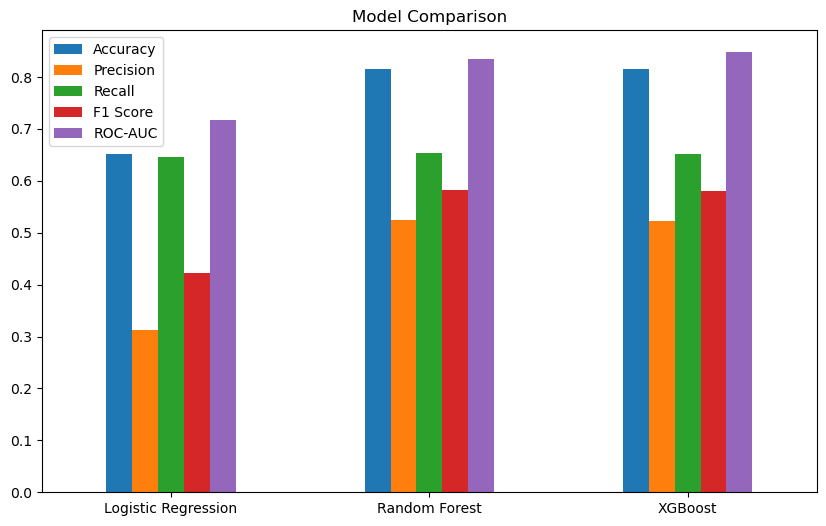

In [24]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [25]:
best_model_name = results_df['F1 Score'].idxmax()
best_model = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [26]:
import joblib

joblib.dump(best_model, "optimized_model.pkl")

['optimized_model.pkl']

# *Conclusion*

<p style='font-size:20px';><i>RandomForest was selected as the best model because it achieved the highest F1-score and ROC-AUC, indicating better balance between precision and recall and superior classification performance compared to other models. This task highlighted the importance of systematic model evaluation and optimization. Selecting the best model based on multiple metrics ensures better generalization and real-world performance."</i></p>